## Load the libraries we need

Here we import the main Python libraries we will use in this project.

- **pandas** for handling normal tabular data
- **geopandas** for spatial data (maps, points, polygons)
- **matplotlib** for quick visual plots
- **json** for reading json files
- **shapely.wkt** to onvert geometry stores as text into real geometry objects

In [103]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
from shapely import wkt

# Schools datasets

## Load the schools dataset

Here we load the two school datasets files wich contains information about all schools in Copenhagen.

For now we just load the dataset and inspect the first few rows to understand the structure.

In [104]:
district_schools = gpd.read_file("../data/raw/distriktsskoler_09032026.gpkg")
special_schools = gpd.read_file("../data/raw/specialskoler_09032026.gpkg")

In [105]:
district_schools.head()

,korttype,borgerrettetnavn,primaer_hjemme_lokation,enhedskategori,specialenhed,ejerforhold,hjemmeside,elevtal,klassetrin,lokationstyper,adresse,postnr_og_postdistrikt,bydel,skoledistrikt,ogc_fid,geometry
0,Skolekort,Den Classenske Legatskole,Ja,Distriktsskole,Nej,Kommunal,https://dcl.aula.dk,515,Bh.kl. - 9.,Distriktsskole,Vester Voldgade 98,1552 København V,Indre By,Den Classenske Legatskole,638,POINT (724837.610 6175474.080)
1,Skolekort,Nyboder Skole,Ja,Distriktsskole,Nej,Kommunal,https://nyboderskole.aula.dk,426,Bh.kl. - 9.,Distriktsskole,Øster Voldgade 15,1350 København K,Indre By,Nyboder Skole,643,POINT (725396.320 6177471.680)
2,Skolekort,Sølvgades Skole,Ja,Distriktsskole,Nej,Kommunal,https://soel.aula.dk,438,Bh.kl. - 9.,Distriktsskole,Sølvgade 16,1307 København K,Indre By,Sølvgades Skole,646,POINT (725231.150 6177008.350)
3,Skolekort,Nørrebro Park Skole,Ja,Distriktsskole,Nej,Kommunal,https://nps.aula.dk,704,Bh.kl. - 9.,Distriktsskole,Jagtvej 34,2200 København N,Nørrebro,Nørrebro Park Skole,649,POINT (722788.310 6177305.740)
4,Skolekort,Blågård Skole,Ja,Distriktsskole,Nej,Kommunal,https://blg.aula.dk,449,Bh.kl. - 9.,Distriktsskole,Hans Tavsens Gade 5,2200 København N,Nørrebro,Blågård Skole,651,POINT (723187.390 6176996.040)


In [106]:
special_schools.head()

,enhedsnavn,forvaltning,enhedstype,ejerforhold,distrikt,www,adresse,nordlig,oestlig,giskoory,giskoorx,skoledistrikt,bydelnavn,lokaludvalgnavn,type,ogc_fid,geometry
0,Frederiksgård Skole,BUF,Skole,Kommunal,Nord,https://frg.aula.dk,"Ørholmgade 8, 2200 København N",12.539096,55.696473,6177975.66,722400.87,Nørrebro Park Skole,Nørrebro,Nørrebro,"Borgerhenvendelse, Specialskole",5,MULTIPOINT (722400.870 6177975.660)
1,Skolen i Peter Vedels Gade,BUF,Skole,Kommunal,Amager,https://petervedelsgade.aula.dk,"Peter Vedels Gade 8, 2300 København S",12.593543,55.665908,6174752.55,725997.09,Amager Fælled Skole,Amager Vest,Amager Vest,"Borgerhenvendelse, Specialskole",21,MULTIPOINT (725997.090 6174752.550)
2,Engskolen,BUF,Skole,Kommunal,Valby-Vesterbro-Kgs. Enghave,https://engskolen.aula.dk,"Haderslevgade 6, 1671 København V",12.545568,55.668303,6174863.50,722967.73,Tove Ditlevsens Skole,Vesterbro-Kongens Enghave,Vesterbro,Specialskole,81,MULTIPOINT (722967.730 6174863.500)
3,Strandparkskolen,BUF,Skole,Kommunal,Indre By-Østerbro,https://strandparkskolen.aula.dk,"Thomas Koppels Allé 10, 2450 København SV",12.530688,55.644987,6172222.74,722164.50,Ellebjerg Skole,Vesterbro-Kongens Enghave,Kongens Enghave,"Borgerhenvendelse, Specialskole",180,MULTIPOINT (722164.500 6172222.740)
4,Specialskolen i Ørestad,BUF,Skole,Kommunal,Indre By-Østerbro,https://specialskolenoerestad-kk.aula.dk/,"Sundholmsvej 50, 2300 København S",12.597929,55.660150,6174126.45,726306.05,Amager Fælled Skole,Amager Vest,Amager Vest,"Borgerhenvendelse, Specialskole",306,MULTIPOINT (726306.053 6174126.448)


## Check the column names

Before doing anything else, we want to see what columns exist in the datasets.

This helps us understand which columns contains coordinates, which columns contains names and attributes and which columns contains the geometry.

In [107]:
district_schools.columns

Index(['korttype', 'borgerrettetnavn', 'primaer_hjemme_lokation',
       'enhedskategori', 'specialenhed', 'ejerforhold', 'hjemmeside',
       'elevtal', 'klassetrin', 'lokationstyper', 'adresse',
       'postnr_og_postdistrikt', 'bydel', 'skoledistrikt', 'ogc_fid',
       'geometry'],
      dtype='object')

In [108]:
special_schools.columns

Index(['enhedsnavn', 'forvaltning', 'enhedstype', 'ejerforhold', 'distrikt',
       'www', 'adresse', 'nordlig', 'oestlig', 'giskoory', 'giskoorx',
       'skoledistrikt', 'bydelnavn', 'lokaludvalgnavn', 'type', 'ogc_fid',
       'geometry'],
      dtype='object')

## Inspect the dataset structure

Here we check the dataset structure, which tells us how many rows there are, hich data types each column has and if there is any values.

In [109]:
district_schools.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   korttype                 60 non-null     object  
 1   borgerrettetnavn         60 non-null     object  
 2   primaer_hjemme_lokation  60 non-null     object  
 3   enhedskategori           60 non-null     object  
 4   specialenhed             60 non-null     object  
 5   ejerforhold              60 non-null     object  
 6   hjemmeside               60 non-null     object  
 7   elevtal                  60 non-null     object  
 8   klassetrin               60 non-null     object  
 9   lokationstyper           60 non-null     object  
 10  adresse                  60 non-null     object  
 11  postnr_og_postdistrikt   60 non-null     object  
 12  bydel                    60 non-null     object  
 13  skoledistrikt            60 non-null     object  
 14  ogc_

In [110]:
special_schools.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   enhedsnavn       13 non-null     object  
 1   forvaltning      13 non-null     object  
 2   enhedstype       13 non-null     object  
 3   ejerforhold      13 non-null     object  
 4   distrikt         13 non-null     object  
 5   www              12 non-null     object  
 6   adresse          13 non-null     object  
 7   nordlig          13 non-null     float64 
 8   oestlig          13 non-null     float64 
 9   giskoory         13 non-null     float64 
 10  giskoorx         13 non-null     float64 
 11  skoledistrikt    13 non-null     object  
 12  bydelnavn        13 non-null     object  
 13  lokaludvalgnavn  13 non-null     object  
 14  type             13 non-null     object  
 15  ogc_fid          13 non-null     int64   
 16  geometry         13 non-null     geome

## Check for missing values

Here we check if any columns contains missing values.

This is important because missing coordinates or geometry could case problems later when working with spatial data.

In [111]:
district_schools.isna()

,korttype,borgerrettetnavn,primaer_hjemme_lokation,enhedskategori,specialenhed,ejerforhold,hjemmeside,elevtal,klassetrin,lokationstyper,adresse,postnr_og_postdistrikt,bydel,skoledistrikt,ogc_fid,geometry
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [112]:
special_schools.isna()

,enhedsnavn,forvaltning,enhedstype,ejerforhold,distrikt,www,adresse,nordlig,oestlig,giskoory,giskoorx,skoledistrikt,bydelnavn,lokaludvalgnavn,type,ogc_fid,geometry
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Check for CRS

We check the CRS for the datasets because we want them to align with our other datasets. This should be EPSG: 25832

In [113]:
district_schools.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Belgium; Denmark - onshore and offshore; Germany - onshore and offshore; Norway including - onshore and offshore; Spain - offshore.
- bounds: (6.0, 38.76, 12.01, 84.33)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [114]:
special_schools.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Belgium; Denmark - onshore and offshore; Germany - onshore and offshore; Norway including - onshore and offshore; Spain - offshore.
- bounds: (6.0, 38.76, 12.01, 84.33)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## Add a school type column for each dataset

Because we have two datasets with different types of schools, we make a new column for each so we can distinguish them later when they are merged.

In [115]:
district_schools["school_type"] = "district_school"
special_schools["school_type"] = "special_school"

## Rename the name column for both datasets to allign them

Rename for both datasets and then only keep the nessesary columns

In [116]:
district_schools = district_schools.rename(columns={"borgerrettetnavn": "school_name"})
special_schools = special_schools.rename(columns={"enhedsnavn": "school_name"})

In [117]:
keep_cols = ["school_name", "school_type", "geometry"]
district_schools = district_schools[keep_cols]
special_schools = special_schools[keep_cols]

## Merge the two school datasets

The district schools and special schools datasets are combined into a single GeoDataFrame.
This new dataset will represent all schools in Copenhagen relevant to the analysis.

The merge is performed using 'pandas.concat()' after which the result is explicitly converted into a GeoDataFrame to preserve the spatial geometry.

In [118]:
schools = pd.concat([district_schools, special_schools], ignore_index=True)
schools = gpd.GeoDataFrame(schools, geometry="geometry")

## Insepct the new merged dataset

In [119]:
schools.head()

,school_name,school_type,geometry
0,Den Classenske Legatskole,district_school,POINT (724837.610 6175474.080)
1,Nyboder Skole,district_school,POINT (725396.320 6177471.680)
2,Sølvgades Skole,district_school,POINT (725231.150 6177008.350)
3,Nørrebro Park Skole,district_school,POINT (722788.310 6177305.740)
4,Blågård Skole,district_school,POINT (723187.390 6176996.040)


In [120]:
schools.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Belgium; Denmark - onshore and offshore; Germany - onshore and offshore; Norway including - onshore and offshore; Spain - offshore.
- bounds: (6.0, 38.76, 12.01, 84.33)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

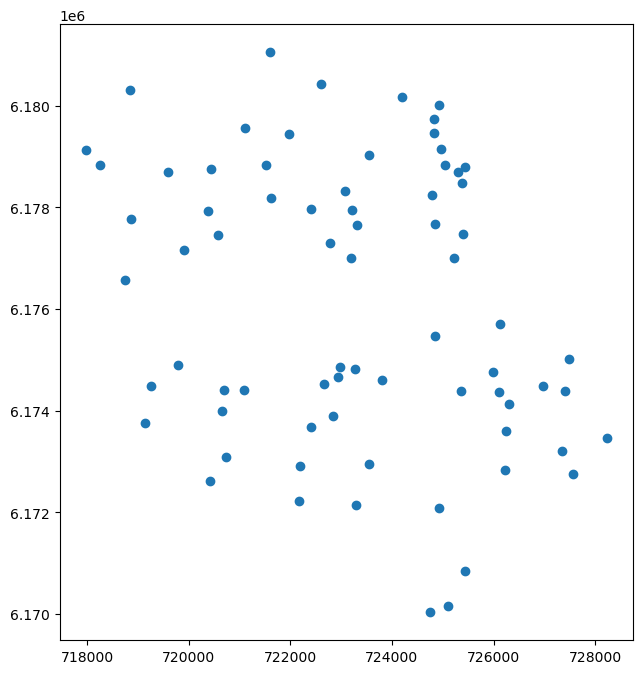

In [121]:
schools.plot(figsize=(8,8))
plt.show()

In [122]:
schools.geom_type.value_counts()

Point         60
MultiPoint    13
Name: count, dtype: int64

In [123]:
schools.geometry.isna().sum()

0

In [124]:
schools.to_file(
    "../data/processed/core_layers.gpkg",
    layer="schools",
    driver="GPKG"
)

# Adresser til brug af skoledistrikter.xlsx

## Load and inspect the school district address dataset

Here we load the address dataset that will later be used to build approximate school district plygons.

First we inspect the columns and data structre to understand which columns identifies the school district, whether geometry is included already and whether coordinates are stores a x and y columns or as text geometry.

In [125]:
addresses_df = pd.read_excel("../data/raw/Adresser til brug af skoledistrikter i KK 2026_02_19.xlsx")
addresses_df.head()

,Koerselsdato,Kommunekode,Kommunenavn,Adresse,Vejkode,Vejnavn,Husnr,Husnummer,Husbogstav,Stednavn,...,Skoledistriktsnr,Skoledistriktsnr_3_cifre,Skoledistriktsnavn,Socialdistriktsnavn,Sognekode,Sognenavn,GIS_koor_X,GIS_koor_Y,Longitude,Latitude
0,2026-02-19,101,København,A-Vej 13,286,A-Vej,13,13,NaN,NaN,...,281053,853,Nordøstamager Skole,Amager,7082,Vor Frelsers,728901.86,6176142.36,12.640786,55.677011
1,2026-02-19,101,København,A.C. Meyers Vænge 1,4734,A.C. Meyers Vænge,1,1,NaN,NaN,...,281060,860,Sluseholmen Skole,Valby-Vesterbro-Kgs. Enghave,9165,Sydhavn,722956.55,6173122.88,12.543978,55.652697
2,2026-02-19,101,København,A.C. Meyers Vænge 2,4734,A.C. Meyers Vænge,2,2,NaN,NaN,...,281060,860,Sluseholmen Skole,Valby-Vesterbro-Kgs. Enghave,9165,Sydhavn,722940.54,6173165.25,12.543759,55.653085
3,2026-02-19,101,København,A.C. Meyers Vænge 3,4734,A.C. Meyers Vænge,3,3,NaN,NaN,...,281060,860,Sluseholmen Skole,Valby-Vesterbro-Kgs. Enghave,9165,Sydhavn,722950.72,6173111.30,12.543876,55.652596
4,2026-02-19,101,København,A.C. Meyers Vænge 4,4734,A.C. Meyers Vænge,4,4,NaN,NaN,...,281060,860,Sluseholmen Skole,Valby-Vesterbro-Kgs. Enghave,9165,Sydhavn,722928.31,6173172.15,12.543570,55.653152


In [126]:
addresses_df.columns

Index(['Koerselsdato', 'Kommunekode', 'Kommunenavn', 'Adresse', 'Vejkode',
       'Vejnavn', 'Husnr', 'Husnummer', 'Husbogstav', 'Stednavn', 'Postnr',
       'Postdistrikt', 'Karrenr', 'Rodenr', 'Rodenavn', 'Lokaludvalgsnr',
       'Lokaludvalgsnavn', 'Bydelsnr', 'Bydelsnavn', 'Omraadenavn',
       'Skoledistriktsnr', 'Skoledistriktsnr_3_cifre', 'Skoledistriktsnavn',
       'Socialdistriktsnavn', 'Sognekode', 'Sognenavn', 'GIS_koor_X',
       'GIS_koor_Y', 'Longitude', 'Latitude'],
      dtype='object')

In [127]:
addresses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85084 entries, 0 to 85083
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Koerselsdato              85084 non-null  datetime64[ns]
 1   Kommunekode               85084 non-null  int64         
 2   Kommunenavn               85084 non-null  object        
 3   Adresse                   85084 non-null  object        
 4   Vejkode                   85084 non-null  int64         
 5   Vejnavn                   85084 non-null  object        
 6   Husnr                     85084 non-null  object        
 7   Husnummer                 85084 non-null  int64         
 8   Husbogstav                16276 non-null  object        
 9   Stednavn                  3307 non-null   object        
 10  Postnr                    85084 non-null  int64         
 11  Postdistrikt              85084 non-null  object        
 12  Karrenr           

In [128]:
addresses_df.isna().sum()

Koerselsdato                    0
Kommunekode                     0
Kommunenavn                     0
Adresse                         0
Vejkode                         0
Vejnavn                         0
Husnr                           0
Husnummer                       0
Husbogstav                  68808
Stednavn                    81777
Postnr                          0
Postdistrikt                    0
Karrenr                       144
Rodenr                          0
Rodenavn                        0
Lokaludvalgsnr                  0
Lokaludvalgsnavn                0
Bydelsnr                        0
Bydelsnavn                      0
Omraadenavn                     0
Skoledistriktsnr                0
Skoledistriktsnr_3_cifre        0
Skoledistriktsnavn              0
Socialdistriktsnavn             0
Sognekode                       0
Sognenavn                       0
GIS_koor_X                     33
GIS_koor_Y                     33
Longitude                      33
Latitude      

## Remove rows without coordinates

A small number of rows are missing spatial coordinates.

Since the coordinates are required to create point geometry, these rows are removed before converting the dataset into a GeoDataFrame.

In [129]:
addresses_df = addresses_df.dropna(subset=["GIS_koor_X", "GIS_koor_Y"])

In [130]:
addresses_df[["GIS_koor_X", "GIS_koor_Y"]].isna().sum()

GIS_koor_X    0
GIS_koor_Y    0
dtype: int64

In [131]:
addresses = gpd.GeoDataFrame(
    addresses_df,
    geometry=gpd.points_from_xy(addresses_df["GIS_koor_X"], addresses_df["GIS_koor_Y"]),
    crs="EPSG:25832"
)

In [132]:
addresses.geometry.head()

0    POINT (728901.860 6176142.360)
1    POINT (722956.550 6173122.880)
2    POINT (722940.540 6173165.250)
3    POINT (722950.720 6173111.300)
4    POINT (722928.310 6173172.150)
Name: geometry, dtype: geometry

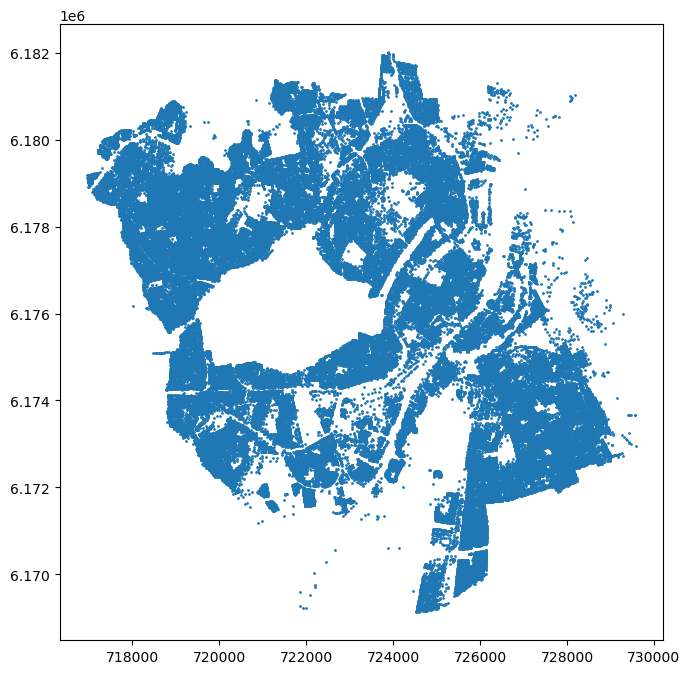

In [133]:
addresses.plot(markersize=1, figsize=(8,8))
plt.show()

## Keep only the usefull columns

The raw address dataset contains many administrative columns, that we dont need.

Here we keep only the columns that are relevant for identifying addresses, school districts and spatial locations.

In [134]:
addresses = addresses[
    [
        "Adresse",
        "Vejnavn",
        "Husnummer",
        "Postnr",
        "Bydelsnavn",
        "Skoledistriktsnr",
        "Skoledistriktsnavn",
        "GIS_koor_X",
        "GIS_koor_Y",
        "geometry"
    ]
]

In [135]:
addresses["Skoledistriktsnr"].nunique()

57

In [136]:
addresses["Skoledistriktsnavn"].value_counts().head()

Skoledistriktsnavn
Distrikt Ørestad             3663
Dyvekeskolen                 3471
Damhusengens Skole           2867
Den Classenske Legatskole    2851
Kirsebærhavens Skole         2665
Name: count, dtype: int64

In [137]:
addresses.groupby("Skoledistriktsnr")["Skoledistriktsnavn"].nunique()

Skoledistriktsnr
101001    1
101003    1
101005    1
101007    1
101008    1
101011    1
101012    1
101015    1
101017    1
101019    1
101020    1
101021    1
101022    1
101023    1
101029    1
101030    1
101034    1
101035    1
101039    1
101041    1
101042    1
101043    1
101045    1
101047    1
101049    1
101050    1
101051    1
101053    1
101055    1
101058    1
101059    1
101060    1
101062    1
101063    1
101064    1
101069    1
101070    1
101074    1
101075    1
101076    1
101138    1
101151    1
101157    1
101174    1
101175    1
101537    1
101540    1
101572    1
101586    1
280129    1
280425    1
280825    1
281053    1
281060    1
281474    1
281980    1
281981    1
Name: Skoledistriktsnavn, dtype: int64

## Save the vleaned address points

Here we save the cleaned adress dataset as a spatial layer in the GeoPackage.

This layer will later be used to build the approximate school district polygons.

In [138]:
addresses.to_file(
    "../data/processed/core_layers.gpkg",
    layer="district_addresses",
    driver="GPKG"
)

# Official School District Polygons

## Load and inspect official school district polygons

In [139]:
districts = gpd.read_file(
    "../data/raw/skolegrunddistrikt_kk_marts2026/skolegrunddistrikt_kk_marts2026.shp"
)

districts.head()

,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,kommunekod,...,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1,geometry
0,5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((12.56885 55.66173, 12.57493 55.66632..."
1,5710,t_5710_born_skole_dis_t,caec40da-f997-11ea-8efa-06d09fa510f4,4af9587a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((12.55322 55.64760, 12.55480 55..."
2,5710,t_5710_born_skole_dis_t,caf771da-f997-11ea-8f2a-06d09fa510f4,4afad1e6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((12.56988 55.61556, 12.56930 55.61550..."
3,5710,t_5710_born_skole_dis_t,cae99b50-f997-11ea-8eca-06d09fa510f4,4afbefd6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((12.55528 55.66973, 12.55526 55.66976..."
4,5710,t_5710_born_skole_dis_t,caf6d3e2-f997-11ea-8f20-06d09fa510f4,4afd1a5a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((12.57390 55.69546, 12.57714 55.69699..."


In [140]:
districts.columns

Index(['temakode', 'temanavn', 'objekt_id', 'versions_i', 'systid_fra',
       'systid_til', 'oprettet', 'cvr_kode', 'cvr_navn', 'kommunekod',
       'bruger_id', 'oprindkode', 'oprindelse', 'statuskode', 'status',
       'off_kode', 'offentlig', 'noegle', 'note', 'udd_distri', 'udd_dist_1',
       'udd_dist_2', 'udd_dist_3', 'starttrin_', 'starttrin', 'sluttrin_k',
       'slutttrin', 'sagsnr', 'link', 'udd_hovedo', 'udd_hove_1', 'udd_delomr',
       'udd_delo_1', 'geometry'],
      dtype='object')

In [141]:
districts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

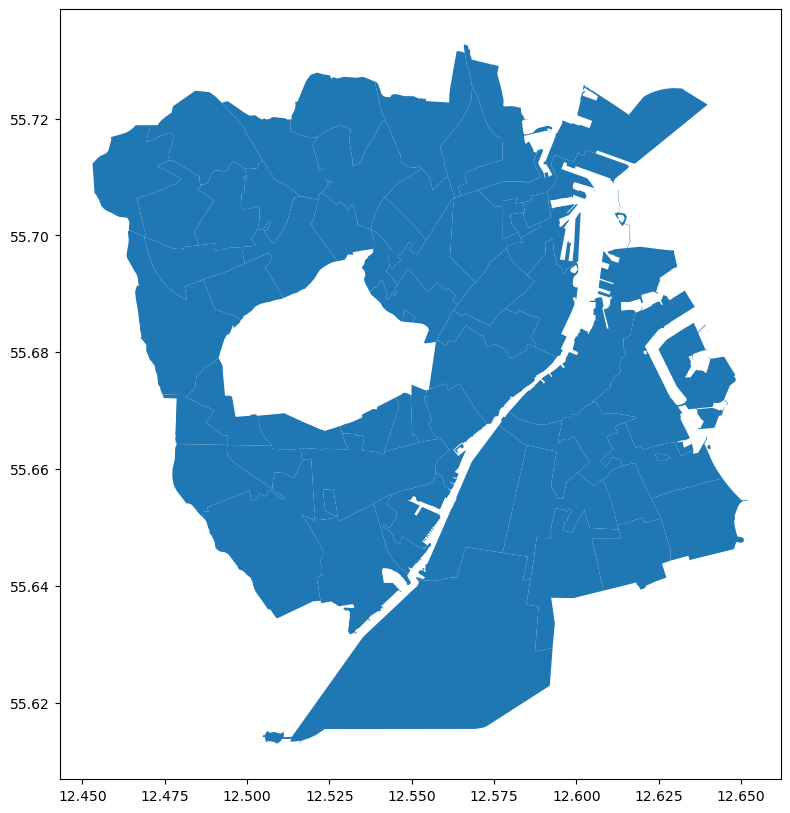

In [142]:
districts.plot(figsize=(10,10))

In [143]:
districts = districts.to_crs(25832)

<Axes: >

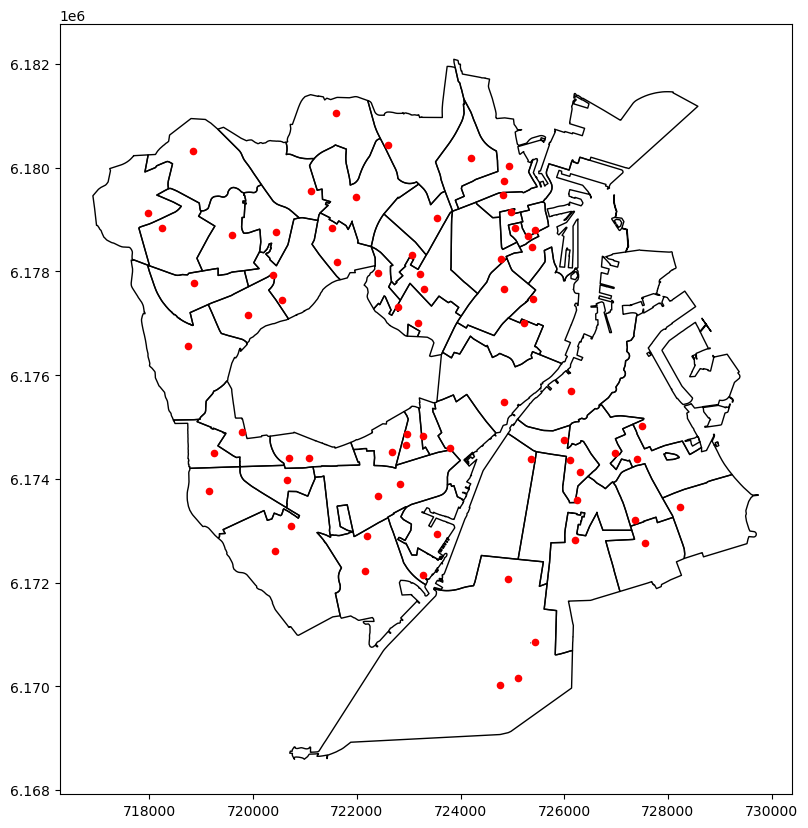

In [144]:
ax = districts.plot(figsize=(10,10), edgecolor="black", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)

## Save the official school disctrict polygons

The official school district polygons from Copenhagen Municipality are used instead of approximate convex hull polygons.

Here we save the cleaned district layer so it can be reused 

In [145]:
districts.to_file(
    "../data/processed/core_layers.gpkg",
    layer="school_districts",
    driver="GPKG"
)

## Match schools to official school district polygons

Here we connect each school point to the official school district polygon it falls within.

This is a useful validation step to check whether the school locations and district polygons align correctly. 

In [146]:
schools_in_districts = gpd.sjoin(
    schools,
    districts,
    how="left",
    predicate="within"
)

schools_in_districts.head()

,school_name,school_type,geometry,index_right,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,...,starttrin_,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1
0,Den Classenske Legatskole,district_school,POINT (724837.610 6175474.080),6,5710,t_5710_born_skole_dis_t,cae9af6e-f997-11ea-8ecc-06d09fa510f4,4affcf5c-a358-11f0-888f-31f687df6650,2025-10-07,NaN,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN
1,Nyboder Skole,district_school,POINT (725396.320 6177471.680),5,5710,t_5710_born_skole_dis_t,caebc81c-f997-11ea-8ef0-06d09fa510f4,4afe47fe-a358-11f0-888f-31f687df6650,2025-10-07,NaN,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN
2,Sølvgades Skole,district_school,POINT (725231.150 6177008.350),8,5710,t_5710_born_skole_dis_t,caebb50c-f997-11ea-8eee-06d09fa510f4,4b032ed6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN
3,Nørrebro Park Skole,district_school,POINT (722788.310 6177305.740),38,5710,t_5710_born_skole_dis_t,cae900be-f997-11ea-8ec2-06d09fa510f4,4b2964e8-a358-11f0-888f-31f687df6650,2025-10-07,NaN,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN
4,Blågård Skole,district_school,POINT (723187.390 6176996.040),26,5710,t_5710_born_skole_dis_t,caea976c-f997-11ea-8ed6-06d09fa510f4,4b1b741e-a358-11f0-888f-31f687df6650,2025-10-07,NaN,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN


## Inspect the joined result

After the spatial join, each school should inherit attributes from the school district polygon it falls within.

Here I inspect the result to see which district information was attached to the schools.

In [147]:
schools_in_districts.columns

Index(['school_name', 'school_type', 'geometry', 'index_right', 'temakode',
       'temanavn', 'objekt_id', 'versions_i', 'systid_fra', 'systid_til',
       'oprettet', 'cvr_kode', 'cvr_navn', 'kommunekod', 'bruger_id',
       'oprindkode', 'oprindelse', 'statuskode', 'status', 'off_kode',
       'offentlig', 'noegle', 'note', 'udd_distri', 'udd_dist_1', 'udd_dist_2',
       'udd_dist_3', 'starttrin_', 'starttrin', 'sluttrin_k', 'slutttrin',
       'sagsnr', 'link', 'udd_hovedo', 'udd_hove_1', 'udd_delomr',
       'udd_delo_1'],
      dtype='object')

In [148]:
districts.head()

,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,kommunekod,...,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1,geometry
0,5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724468.727 6174207.618, 724824.483 6..."
1,5710,t_5710_born_skole_dis_t,caec40da-f997-11ea-8efa-06d09fa510f4,4af9587a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((723566.615 6172586.107, 723670..."
2,5710,t_5710_born_skole_dis_t,caf771da-f997-11ea-8f2a-06d09fa510f4,4afad1e6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724798.236 6169075.917, 724761.682 6..."
3,5710,t_5710_born_skole_dis_t,cae99b50-f997-11ea-8eca-06d09fa510f4,4afbefd6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((723570.181 6175053.926, 723568.928 6..."
4,5710,t_5710_born_skole_dis_t,caf6d3e2-f997-11ea-8f20-06d09fa510f4,4afd1a5a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724592.495 6177975.285, 724787.236 6..."


In [149]:
districts[["temanavn", "udd_distri", "udd_dist_1", "udd_dist_2", "udd_dist_3"]].head()

,temanavn,udd_distri,udd_dist_1,udd_dist_2,udd_dist_3
0,t_5710_born_skole_dis_t,101059,Skolen på Islands Brygge,5,Skole
1,t_5710_born_skole_dis_t,280129,Skolen i Sydhavnen,5,Skole
2,t_5710_born_skole_dis_t,281474,Distrikt Ørestad,5,Skole
3,t_5710_born_skole_dis_t,101586,Skolen ved Dybbølsbro,5,Skole
4,t_5710_born_skole_dis_t,101043,Øster Farimagsgades Skole,5,Skole


## Inspect which district each school was matched to

The columns 'udd_distri' and 'udd_dist_1' appear to contain the official district code and district name.

Here we inspect which official district each school was mathed to in the spatial join.

In [150]:
schools_in_districts[["school_name", "udd_distri", "udd_dist_1"]].head(10)

,school_name,udd_distri,udd_dist_1
0,Den Classenske Legatskole,101001,Den Classenske Legatskole
1,Nyboder Skole,101003,Nyboder Skole
2,Sølvgades Skole,101005,Sølvgades Skole
3,Nørrebro Park Skole,101007,Nørrebro Park Skole
4,Blågård Skole,101008,Blågård Skole
5,Bellahøj Skole,101011,Bellahøj Skole
6,Brønshøj Skole,101012,Brønshøj Skole
7,Grøndalsvængets Skole,101015,Grøndalsvængets Skole
8,Husum Skole,101017,Husum Skole
9,Katrinedals Skole,101019,Katrinedals Skole


## Check whether any shools were not mached to a district

If the spatial join worked correctly, every school should be matched to one district polygon.

Here we therefore check whether any shcools where left unmatched.

In [151]:
schools_in_districts["index_right"].isna().sum()

0

In [152]:
schools_in_districts["udd_dist_1"].value_counts().head(50)

udd_dist_1
Distrikt Ørestad               4
Amager Fælled Skole            3
Grøndalsvængets Skole          2
Guldberg Skole                 2
Rødkilde Skole                 2
Valby Skole                    2
Skolen på Strandboulevarden    2
Bavnehøj Skole                 2
Tove Ditlevsens Skole          2
Ellebjerg Skole                2
Nørrebro Park Skole            2
Kirsebærhavens Skole           2
Strandvejsskolen               2
Oehlenschlægersgades Skole     1
Hanssted Skole                 1
Sortedamskolen                 1
Vigerslev Allés Skole          1
Ålholm Skole                   1
Lundehusskolen                 1
Kildevældsskolen               1
Den Classenske Legatskole      1
Langelinieskolen               1
Peder Lykke Skolen             1
Utterslev Skole                1
Vesterbro Ny Skole             1
Skolen ved Dybbølsbro          1
Skolen i Sydhavnen             1
Damhusengens Skole             1
Nordøstamager Skole            1
Sluseholmen Skole              1

## Save the school-to-district match layer

Here we save the joined school and distrct dataset so it can be resued later in the project.

In [153]:
schools_in_districts.to_file(
    "../data/processed/core_layers.gpkg",
    layer="schools_in_districts",
    driver="GPKG"
)